# Cronbach's alpha for the factor-analysis items

This notebook estimates internal consistency for each factor from the existing eight-factor solution. Variables are assigned to factors from `FA_n8_loadings_full.csv`, and observations come from `data_FactorAnalysis_var106.csv`.

Because the variables use different units, the primary result is **standardized Cronbach's alpha**. Items with negative loadings are sign-reversed so that all items point in the same factor direction. Alpha describes internal consistency; it is not, by itself, evidence that a factor is unidimensional.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project and analysis settings
REPO_ROOT = Path('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI')
DATA_DIR = REPO_ROOT / 'data' / 'FactorAnalysis'
ITEM_DATA_FILE = DATA_DIR / 'data_FactorAnalysis_var106.csv'
LOADINGS_FILE = DATA_DIR / 'FA_n8_loadings_full.csv'
OUTPUT_FILE = DATA_DIR / 'cronbach_alpha_FA_n8.csv'
ITEM_OUTPUT_FILE = DATA_DIR / 'cronbach_alpha_FA_n8_item_diagnostics.csv'

LOADING_CUTOFF = 0.40
ASSIGNMENT = 'all'  # 'primary': strongest factor only; 'all': include every loading >= cutoff
REVERSE_NEGATIVE_LOADINGS = True
MIN_ITEMS = 2

assert ITEM_DATA_FILE.exists(), f'Missing item data: {ITEM_DATA_FILE}'
assert LOADINGS_FILE.exists(), f'Missing loading table: {LOADINGS_FILE}'
print(f'Item data: {ITEM_DATA_FILE}')
print(f'Loadings:  {LOADINGS_FILE}')

/home/xy6/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Item data: /work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/data_FactorAnalysis_var106.csv
Loadings:  /work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/FA_n8_loadings_full.csv


## Load and validate inputs

The first column of the loading table is treated as the variable name (it is called `index` in the current output). Only numeric factor columns are used.

In [2]:
item_data = pd.read_csv(ITEM_DATA_FILE)
loadings_raw = pd.read_csv(LOADINGS_FILE)

item_name_col = loadings_raw.columns[0]
loadings = loadings_raw.set_index(item_name_col)
loadings = loadings.apply(pd.to_numeric, errors='coerce')
factor_cols = [c for c in loadings.columns if loadings[c].notna().any()]
loadings = loadings[factor_cols]

missing_items = loadings.index.difference(item_data.columns)
if len(missing_items):
    raise ValueError(f'{len(missing_items)} loading-table items are absent from the item data: {list(missing_items[:10])}')
if item_data.columns.duplicated().any() or loadings.index.duplicated().any():
    raise ValueError('Duplicate item names were found in an input file.')

print(f'{item_data.shape[0]:,} observations x {item_data.shape[1]} items')
print(f'{len(factor_cols)} factors: {factor_cols}')
display(loadings.head())

13,850 observations x 106 items
8 factors: ['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5', 'Factor 6', 'Factor 7', 'Factor 8']


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8
index,,,,,,,,
CD_Blog_LemmaSum,0.958,0.008,0.004,0.000,0.003,-0.019,0.022,0.013
Freq_Blog_LemmaSum,0.955,0.005,0.002,-0.004,0.004,-0.008,0.021,0.016
CD_SUBTLEXUK_LemmaSum,0.953,-0.015,0.007,0.018,-0.004,-0.012,0.016,-0.010
CD_News_LemmaSum,0.944,0.059,0.010,-0.015,0.012,-0.017,0.099,-0.079
Freq_SUBTLEXUK_Zipf_LemmaSum,0.943,-0.022,-0.004,0.003,-0.005,0.026,-0.001,0.006


## Reliability functions

Rows with a missing value in any selected item are removed factor by factor (complete-case analysis). The item-rest correlation correlates each signed, standardized item with the sum of the other items. `alpha_if_deleted` helps identify items that reduce consistency.

In [3]:
def cronbach_alpha(values):
    """Raw alpha for a complete numeric matrix (rows=observations, columns=items)."""
    x = np.asarray(values, dtype=float)
    n_obs, n_items = x.shape
    if n_items < 2 or n_obs < 2:
        return np.nan
    item_variances = np.var(x, axis=0, ddof=1)
    total_variance = np.var(x.sum(axis=1), ddof=1)
    if not np.isfinite(total_variance) or total_variance <= 0:
        return np.nan
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)

def prepare_factor_items(data, factor_loadings, reverse_negative=True):
    x = data.loc[:, factor_loadings.index].apply(pd.to_numeric, errors='coerce').dropna(axis=0, how='any')
    # Remove constant items before standardizing; alpha is undefined for them.
    constant = x.columns[x.std(ddof=1).eq(0) | x.std(ddof=1).isna()].tolist()
    x = x.drop(columns=constant)
    signs = np.sign(factor_loadings.loc[x.columns]).replace(0, 1) if reverse_negative else pd.Series(1, index=x.columns)
    signed = x.mul(signs, axis=1)
    standardized = (signed - signed.mean()) / signed.std(ddof=1)
    return signed, standardized, signs, constant

def reliability_for_factor(data, factor, factor_loadings):
    signed, z, signs, constant = prepare_factor_items(data, factor_loadings, REVERSE_NEGATIVE_LOADINGS)
    result = {
        'factor': factor, 'n_items': z.shape[1], 'n_observations': z.shape[0],
        'standardized_alpha': cronbach_alpha(z),
        'raw_alpha_after_signing': cronbach_alpha(signed),
        'mean_inter_item_correlation': z.corr().where(~np.eye(z.shape[1], dtype=bool)).stack().mean() if z.shape[1] >= 2 else np.nan,
        'n_negative_items_reversed': int((signs < 0).sum()),
        'constant_items_removed': '; '.join(constant),
        'items': '; '.join(z.columns),
    }
    diagnostics = []
    for item in z.columns:
        other_items = z.columns.difference([item], sort=False)
        item_rest = z[item].corr(z[other_items].sum(axis=1)) if len(other_items) else np.nan
        diagnostics.append({
            'factor': factor, 'item': item, 'loading': factor_loadings[item],
            'reversed': bool(signs[item] < 0), 'item_rest_correlation': item_rest,
            'alpha_if_deleted': cronbach_alpha(z[other_items]) if len(other_items) >= 2 else np.nan,
        })
    return result, diagnostics


## Assign items and calculate alpha

With `ASSIGNMENT = 'primary'`, an item is assigned only to the factor on which it has the largest absolute loading, provided that loading reaches the cutoff. This prevents cross-loading items from appearing in multiple scales. Change the setting to `'all'` to reproduce a threshold-only assignment.

In [4]:
if ASSIGNMENT not in {'primary', 'all'}:
    raise ValueError("ASSIGNMENT must be 'primary' or 'all'.")
ASSIGNMENT = 'all'
assignments = {}
if ASSIGNMENT == 'primary':
    primary_factor = loadings.abs().idxmax(axis=1)
    primary_loading = pd.Series(
        [loadings.loc[item, factor] for item, factor in primary_factor.items()],
        index=loadings.index, dtype=float
    )
    for factor in factor_cols:
        selected = primary_factor.eq(factor) & primary_loading.abs().ge(LOADING_CUTOFF)
        assignments[factor] = primary_loading[selected]
else:
    for factor in factor_cols:
        assignments[factor] = loadings.loc[loadings[factor].abs().ge(LOADING_CUTOFF), factor]

results, diagnostics = [], []
for factor, factor_loadings in assignments.items():
    if len(factor_loadings) < MIN_ITEMS:
        results.append({'factor': factor, 'n_items': len(factor_loadings), 'n_observations': np.nan,
                        'standardized_alpha': np.nan, 'raw_alpha_after_signing': np.nan,
                        'mean_inter_item_correlation': np.nan, 'n_negative_items_reversed': np.nan,
                        'constant_items_removed': '', 'items': '; '.join(factor_loadings.index)})
        print(f'Warning: {factor} has fewer than {MIN_ITEMS} selected items; alpha was not calculated.')
        continue
    result, item_rows = reliability_for_factor(item_data, factor, factor_loadings)
    results.append(result)
    diagnostics.extend(item_rows)

alpha_results = pd.DataFrame(results)
item_diagnostics = pd.DataFrame(diagnostics)
alpha_results.to_csv(OUTPUT_FILE, index=False)
item_diagnostics.to_csv(ITEM_OUTPUT_FILE, index=False)

display(alpha_results.round(3))
print(f'Saved factor results to: {OUTPUT_FILE}')
print(f'Saved item diagnostics to: {ITEM_OUTPUT_FILE}')

,factor,n_items,n_observations,standardized_alpha,raw_alpha_after_signing,mean_inter_item_correlation,n_negative_items_reversed,constant_items_removed,items
0,Factor 1,21,13850,0.975,0.008,0.650,2,,CD_Blog_LemmaSum; Freq_Blog_LemmaSum; CD_SUBTL...
1,Factor 2,19,13850,0.958,0.844,0.545,9,,OLD20; PLD20; NLett; OUP; NPhon; PUP; NSyll; N...
2,Factor 3,8,13850,0.946,0.932,0.687,0,,Consistency_Token_FB; Consistency_Type_FB; Con...
3,Factor 4,8,13850,0.929,0.904,0.621,0,,Consistency_Token_FF; Consistency_Type_FF; Con...
4,Factor 5,11,13850,0.900,0.565,0.450,0,,UniphonP_St_C; UniphonP_Un_C; UniphonP_Un; Uni...
5,Factor 6,8,13850,0.821,0.787,0.365,3,,AoA_Kuper; AoA_LWV; Conc_Brys; Visual_Lanc; Ha...
6,Factor 7,4,13850,0.998,0.983,0.994,0,,Sem_N_D_Taxonomic_N10; Sem_N_D_Taxonomic_N25; ...
7,Factor 8,7,13850,0.808,0.684,0.376,0,,Interoceptive_Lanc; Assoc_Freq_Token123; Assoc...


Saved factor results to: /work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/cronbach_alpha_FA_n8.csv
Saved item diagnostics to: /work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/data/FactorAnalysis/cronbach_alpha_FA_n8_item_diagnostics.csv


## Inspect item diagnostics and plot results

Negative alpha or low item-rest correlations can indicate an incorrectly oriented item, heterogeneous items, or a factor that is not well represented as a single additive scale. Interpret common alpha thresholds cautiously and in light of the number of items and the construct.

,factor,item,loading,reversed,item_rest_correlation,alpha_if_deleted
18,Factor 1,Sem_Diversity,0.421,False,0.402,0.977
17,Factor 1,Sem_N_D,0.463,False,0.436,0.977
16,Factor 1,Nsenses_WordNet,0.491,False,0.515,0.976
19,Factor 1,AoA_Kuper,-0.524,True,0.575,0.976
20,Factor 1,AoA_LWV,-0.531,True,0.589,0.976
...,...,...,...,...,...,...
84,Factor 8,Mink_Action_Lanc,0.482,False,0.325,0.820
83,Factor 8,Assoc_Freq_Token,0.779,False,0.756,0.744
82,Factor 8,Assoc_Freq_Type123,0.779,False,0.784,0.738
80,Factor 8,Assoc_Freq_Token123,0.800,False,0.785,0.738


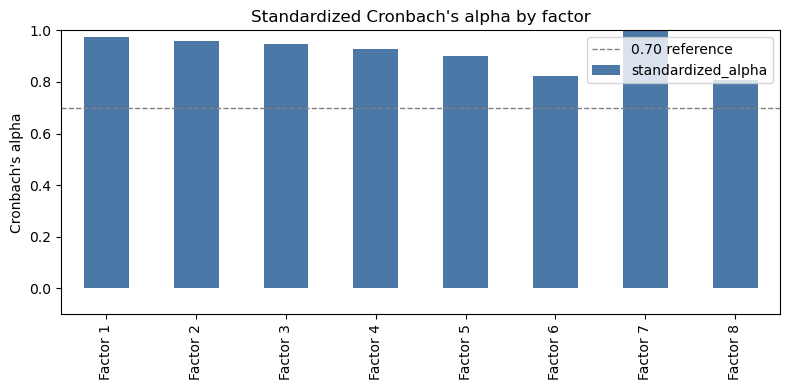

In [5]:
display(item_diagnostics.sort_values(['factor', 'item_rest_correlation']).round(3))

plot_data = alpha_results.dropna(subset=['standardized_alpha'])
ax = plot_data.plot.bar(x='factor', y='standardized_alpha', legend=False, figsize=(8, 4), color='#4C78A8')
ax.axhline(0.70, color='gray', linestyle='--', linewidth=1, label='0.70 reference')
ax.set(title="Standardized Cronbach's alpha by factor", xlabel='', ylabel="Cronbach's alpha", ylim=(min(-0.1, plot_data['standardized_alpha'].min() - 0.05), 1.0))
ax.legend()
plt.tight_layout()
plt.show()